# FDDES Project 2026

This is the main working file of the project. Here, we review the computations done in "fdd/...". This acts as the main pipeline (imports and runs preprocessing, fd-methods, evaluation, etc).   

## Faulty cases - Ground truth
We know the start and end times of the faults in the different cases which serves as a ground truth to compare the results with.

In [1]:
SEfc1_1 = [1566, 5181] # Fault start and end for FaultyCase1 set 1.1
SEfc1_2 = [657, 3777]
SEfc1_3 = [691, 3691]

SEfc2_1 = [2244, 6616]
SEfc2_2 = [476, 2656]
SEfc2_3 = [331, 2467]

SEfc3_1 = [1136, 8352]
SEfc3_2 = [333, 5871]
SEfc3_3 = [596, 9566]

SEfc4_1 = [953, 6294]
SEfc4_2 = [851, 3851]
SEfc4_3 = [241, 3241]

SEfc5_1 = [686, 1172, 1772, 2253] # Fault start and end for FaultyCase5 set 5.1 with two faults
SEfc5_2 = [1633, 2955, 7031, 7553, 8057, 10608] # with three faults

SEfc6_1 = [1723, 2800]
SEfc6_2 = [1037, 4830]

se_windows = {
    "FaultyCase1": [SEfc1_1, SEfc1_2, SEfc1_3],
    "FaultyCase2": [SEfc2_1, SEfc2_2, SEfc2_3],
    "FaultyCase3": [SEfc3_1, SEfc3_2, SEfc3_3],
    "FaultyCase4": [SEfc4_1, SEfc4_2, SEfc4_3],
    "FaultyCase5": [SEfc5_1, SEfc5_2],
    "FaultyCase6": [SEfc6_1, SEfc6_2],
}

In [2]:
import matplotlib.pyplot as plt
import numpy as np

## Data loading

In [3]:
from fdd.dataloader import DataLoader
from fdd.preprocessor import StandardPreprocessor

loader = DataLoader()

# Training data 
trainsets = loader.load("Training")

# Faulty cases (test data)
FC1sets = loader.load("FaultyCase1")
FC2sets = loader.load("FaultyCase2")
FC3sets = loader.load("FaultyCase3")
FC4sets = loader.load("FaultyCase4")
FC5sets = loader.load("FaultyCase5")
FC6sets = loader.load("FaultyCase6")
fc_sets = [FC1sets, FC2sets, FC3sets, FC4sets, FC5sets, FC6sets]

# Training

## Preprocessing

In [4]:
# Centering and scaling

train_set_1 = trainsets["T1"] # others are "T2" and "T3"
print(train_set_1.summary())

preprocessor = StandardPreprocessor(with_standardization=True)
X_processed = preprocessor.fit_transform(train_set_1)

X_processed.sensors.head()

TimeSeriesDataset(name=T1, n_samples=10372, n_features=23)


,Air_Delivery_P,P_Bottom_Riser,P_Top_Riser,P_Top_Separator,P_3Phase_Separator,Diff_P_Riser,Diff_P_VC404,Air_In_Flow,Water_In_Flow,Flow_Top_Riser,...,Density_Top_Sep_Out,Density_Water_In,Temp_Top_Riser,Temp_Top_Sep_Out,Temp_Water_In,Level_3Phase_Sep,Pos_VC501,Pos_VC302,Pos_VC101,Pump_Current_PO1
0,-1.437195,-1.371980,-0.816336,-0.559184,-0.633159,-1.179499,-0.638294,-1.226225,-1.096560,-0.547632,...,0.541646,0.450026,1.521277,1.980402,0.651681,1.018815,-1.399210,-1.287813,-1.114830,-1.359768
1,-1.432961,-1.367098,-0.801770,-0.541074,-0.609245,-1.172216,-0.617034,-1.195433,-1.096552,-0.547634,...,0.541434,0.449249,1.510648,1.974524,0.774889,1.013263,-1.402489,-1.295797,-1.114843,-1.595380
2,-1.428350,-1.368818,-0.749364,-0.522919,-0.585314,-1.172762,-0.521361,-1.184190,-1.096545,-0.547635,...,0.541222,0.448277,1.500020,1.968650,0.774889,1.007713,-1.405764,-1.303780,-1.114856,-1.006349
3,-1.423731,-1.363055,-0.769740,-0.504814,-0.561391,-1.173308,-0.726880,-1.184610,-1.096537,-0.547637,...,0.541010,0.447500,1.489392,1.962775,0.774889,1.002156,-1.409040,-1.308472,-1.114870,-1.438305
4,-1.419120,-1.351676,-0.766810,-0.514497,-0.537469,-1.168822,-0.755228,-1.199208,-1.096529,-0.547638,...,0.540798,0.446528,1.478761,1.956900,0.779823,0.996604,-1.412319,-1.309872,-1.114883,-2.341485


## PCA

Original X shape: (10372, 23)
PCA-transformed Z shape: (10372, 2)
Explained variance ratio: [0.47201557 0.20494557]
Cumulative explained variance: [0.47201557 0.67696115]
Total explained variance: 0.6769611467392285
         Z1        Z2
0  3.158374 -2.554867
1  3.215427 -2.546264
2  3.116147 -2.503575
3  3.221971 -2.517498
4  3.239647 -2.545264


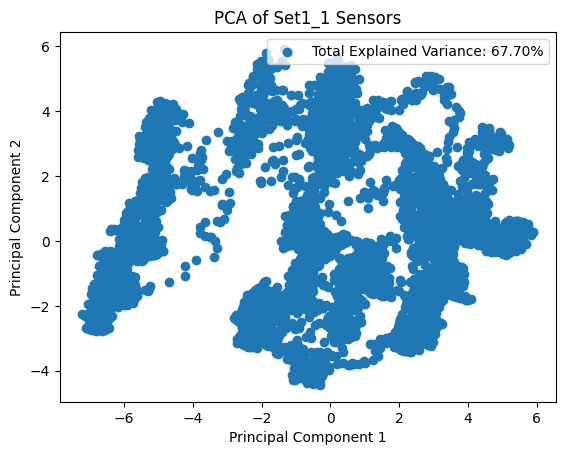

In [5]:
from fdd.pca import pca_fit
from fdd.pca import pca_transform

# X from preprocessing
X = X_processed.sensors

pca_model = pca_fit(X, n_components=2)
Z_pca = pca_transform(X, pca_model)
evr_pca = pca_model["explained_variance_ratio"]

print('Original X shape:', X.shape)
print('PCA-transformed Z shape:', Z_pca.shape)
print('Explained variance ratio:', evr_pca.values)
print('Cumulative explained variance:', evr_pca.cumsum().values)
print('Total explained variance:', evr_pca.sum())
print(Z_pca.head())

plt.scatter(Z_pca["Z1"], Z_pca["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA of Set1_1 Sensors")
plt.legend([f'Total Explained Variance: {evr_pca.sum()*100:.2f}%'])          
plt.show()

The total explained variance is only 47% meaning only 47% of the data can be explained with these two principal components. Therefore a 2D PCA is mainly used for visualization and not as a complete representation. 

Since X has been reduced down to 2 "features" in Z, that makes us able to plot them.

### Q and T2 statistics for PCA

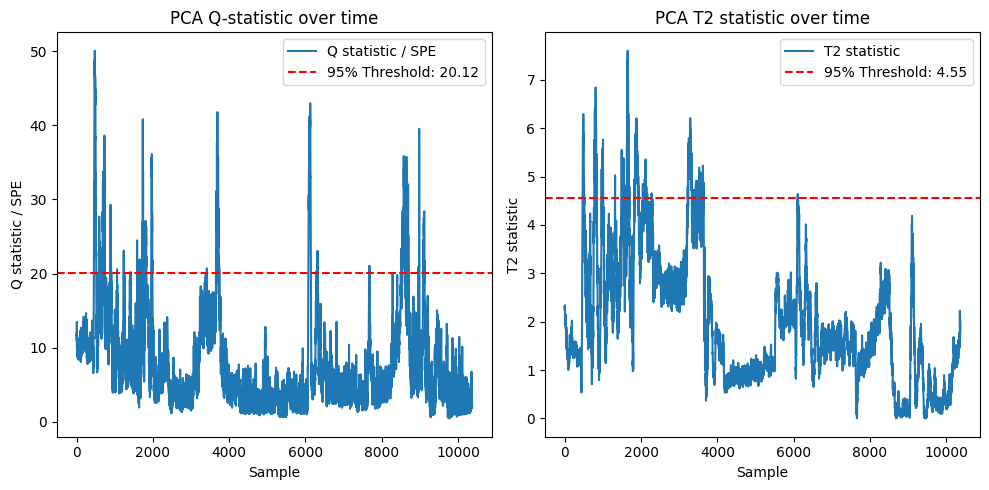

In [6]:
# Q-statistic
from fdd.statistics import q_statistic
q_train_pca = q_statistic(X, Z_pca)
threshold_q_pca = np.percentile(q_train_pca, 95)

# Hotteling's T2 statistic
from fdd.statistics import t2_statistic
t2_train_pca = t2_statistic(Z_pca)
threshold_t2_pca = np.percentile(t2_train_pca, 95)

# Plot Q-statistic and T2 statistic over time with thresholds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q_train_pca, label='Q statistic / SPE')
plt.axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_pca:.2f}')
plt.xlabel("Sample")
plt.ylabel("Q statistic / SPE")
plt.title("PCA Q-statistic over time")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(t2_train_pca, label='T2 statistic')
plt.axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_pca:.2f}')
plt.xlabel("Sample")
plt.ylabel("T2 statistic")
plt.title("PCA T2 statistic over time")
plt.legend()
plt.tight_layout()
plt.show()

When finding the thresholds during training, a 95% threshold means that you can expect about 5% false alarms. 

## DPCA transform

Original X shape: (10372, 23)
DPCA-transformed Z shape: (10367, 2)
Explained variance ratio: [0.47121075 0.20439447]
Cumulative explained variance: [0.47121075 0.67560522]
Total explained variance: 0.6756052246948808
         Z1        Z2
5  7.724041 -6.202630
6  7.600972 -6.184793
7  7.470835 -6.194895
8  7.346702 -6.239781
9  7.107691 -6.272626


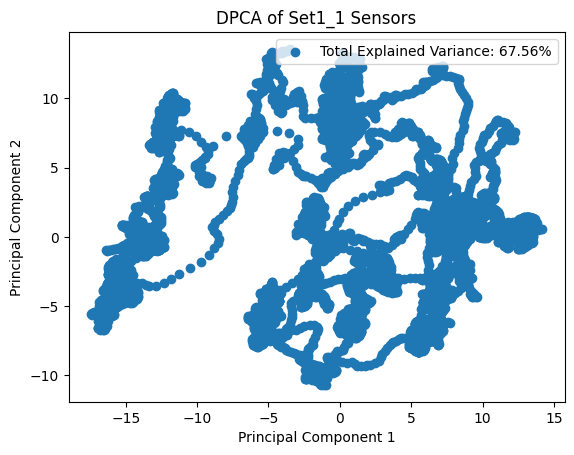

In [7]:
from fdd.dpca import dpca_fit
from fdd.dpca import dpca_transform
from fdd.dpca import dpca_prepare_matrix

dpca_model = dpca_fit(X, n_components=2, time_lags=5)
evr_dpca = dpca_model["explained_variance_ratio"]
Z_dpca = dpca_transform(X, dpca_model)

print('Original X shape:', X.shape)
print('DPCA-transformed Z shape:', Z_dpca.shape)
print('Explained variance ratio:', evr_dpca.values)
print('Cumulative explained variance:', evr_dpca.cumsum().values)
print('Total explained variance:', evr_dpca.sum())
print(Z_dpca.head())

plt.scatter(Z_dpca["Z1"], Z_dpca["Z2"])
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("DPCA of Set1_1 Sensors")
plt.legend([f'Total Explained Variance: {evr_dpca.sum()*100:.2f}%'])          
plt.show()

### Q and T2 statistic for DPCA

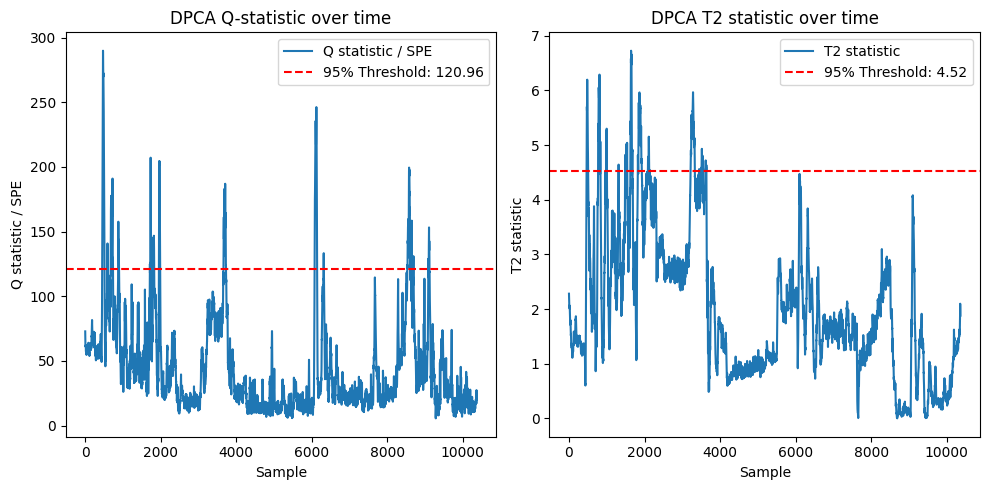

In [8]:
# Q-statistic
from fdd.statistics import q_statistic

X_lagged = dpca_prepare_matrix(X, dpca_model)

q_values_dpca = q_statistic(X_lagged, Z_dpca) # Remember to use lagged X for DPCA
threshold_q_dpca = np.percentile(q_values_dpca, 95)

# Hotteling's T2 statistic
from fdd.statistics import t2_statistic
t2_values_dpca = t2_statistic(Z_dpca)
threshold_t2_dpca = np.percentile(t2_values_dpca, 95)

# Plot Q-statistic and T2 statistic over time with thresholds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q_values_dpca, label='Q statistic / SPE')
plt.axhline(y=threshold_q_dpca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_dpca:.2f}')
plt.xlabel("Sample")
plt.ylabel("Q statistic / SPE")
plt.title("DPCA Q-statistic over time")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(t2_values_dpca, label='T2 statistic')
plt.axhline(y=threshold_t2_dpca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_dpca:.2f}')
plt.xlabel("Sample")
plt.ylabel("T2 statistic")
plt.title("DPCA T2 statistic over time")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
Z_dpca.head()

,Z1,Z2
5,7.724041,-6.202630
6,7.600972,-6.184793
7,7.470835,-6.194895
8,7.346702,-6.239781
9,7.107691,-6.272626


## FDA transform

# Testing - Faulty cases

PCA on FC1_1: Number of Q-statistic anomalies: 5811 of 5811 samples
PCA on FC1_1: Number of T2 statistic anomalies: 740 of 5811 samples


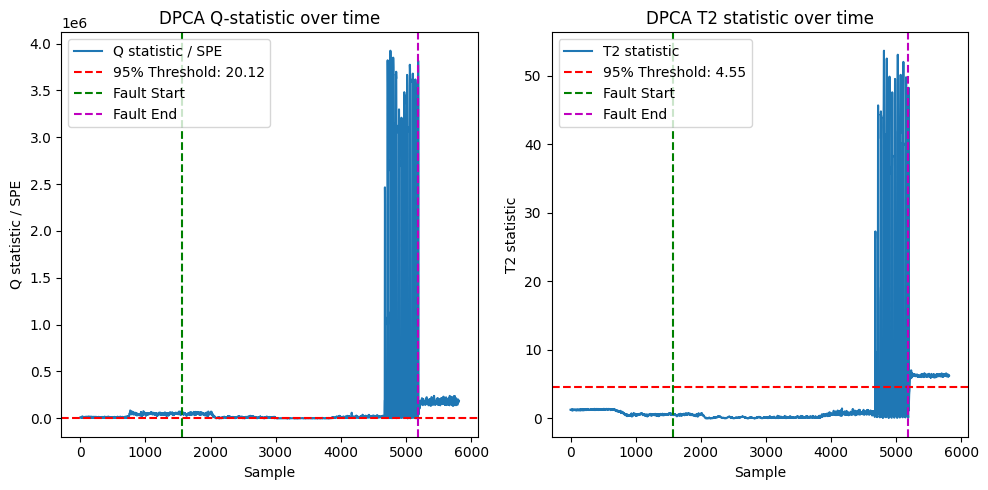

In [10]:
X_FC1_1 = FC1sets["Set1_1"].sensors
Z_FC1_1 = pca_transform(X_FC1_1, pca_model)
q_FC1_1 = q_statistic(X_FC1_1, Z_FC1_1)
t2_FC1_1 = t2_statistic(Z_FC1_1)

# How many of all samples are over the thresholds?
n_q_anomalies = np.sum(q_FC1_1 > threshold_q_pca)
n_t2_anomalies = np.sum(t2_FC1_1 > threshold_t2_pca)
print(f"PCA on FC1_1: Number of Q-statistic anomalies: {n_q_anomalies} of {len(q_FC1_1)} samples")
print(f"PCA on FC1_1: Number of T2 statistic anomalies: {n_t2_anomalies} of {len(t2_FC1_1)} samples")

# Plot Q-statistic and T2 statistic over time with thresholds
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(q_FC1_1, label='Q statistic / SPE')
plt.axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_pca:.2f}')
plt.axvline(x=SEfc1_1[0], color='g', linestyle='--', label='Fault Start')
plt.axvline(x=SEfc1_1[1], color='m', linestyle='--', label='Fault End')
plt.xlabel("Sample")
plt.ylabel("Q statistic / SPE")
plt.title("DPCA Q-statistic over time")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(t2_FC1_1, label='T2 statistic')
plt.axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_pca:.2f}')
plt.axvline(x=SEfc1_1[0], color='g', linestyle='--', label='Fault Start')
plt.axvline(x=SEfc1_1[1], color='m', linestyle='--', label='Fault End')
plt.xlabel("Sample")
plt.ylabel("T2 statistic")
plt.title("DPCA T2 statistic over time")
plt.legend()
plt.tight_layout()
plt.show()

PCA on FaultyCase1 Set1_1: Number of Q-statistic anomalies: 5811 of 5811 samples
PCA on FaultyCase1 Set1_1: Number of T2 statistic anomalies: 740 of 5811 samples


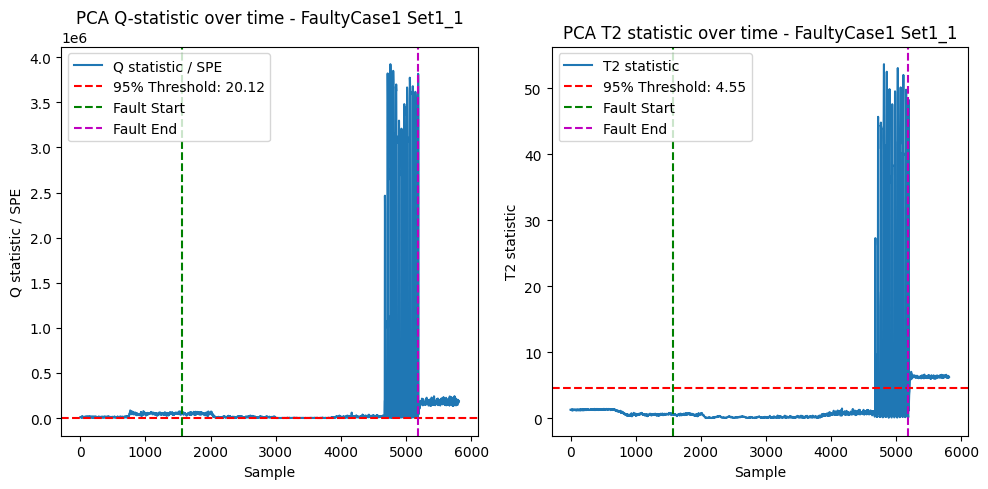

PCA on FaultyCase1 Set1_2: Number of Q-statistic anomalies: 4467 of 4467 samples
PCA on FaultyCase1 Set1_2: Number of T2 statistic anomalies: 990 of 4467 samples


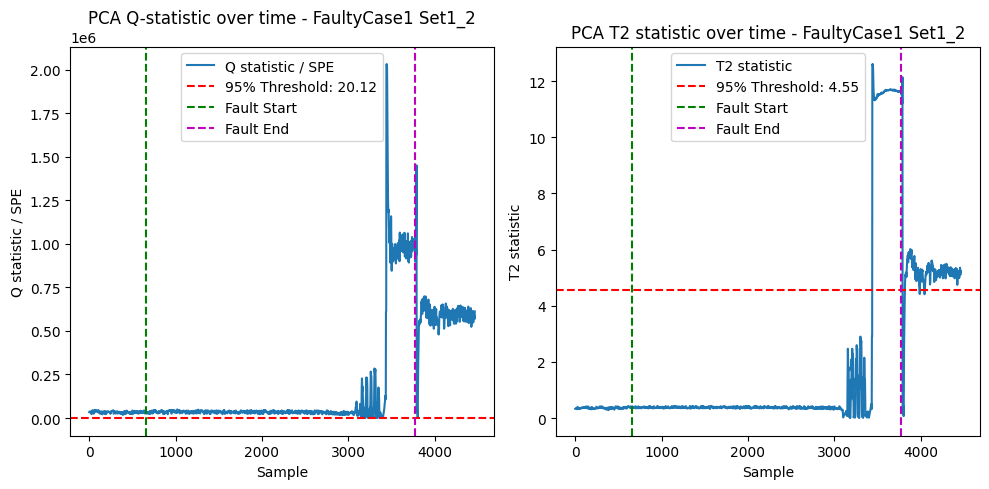

PCA on FaultyCase1 Set1_3: Number of Q-statistic anomalies: 4321 of 4321 samples
PCA on FaultyCase1 Set1_3: Number of T2 statistic anomalies: 515 of 4321 samples


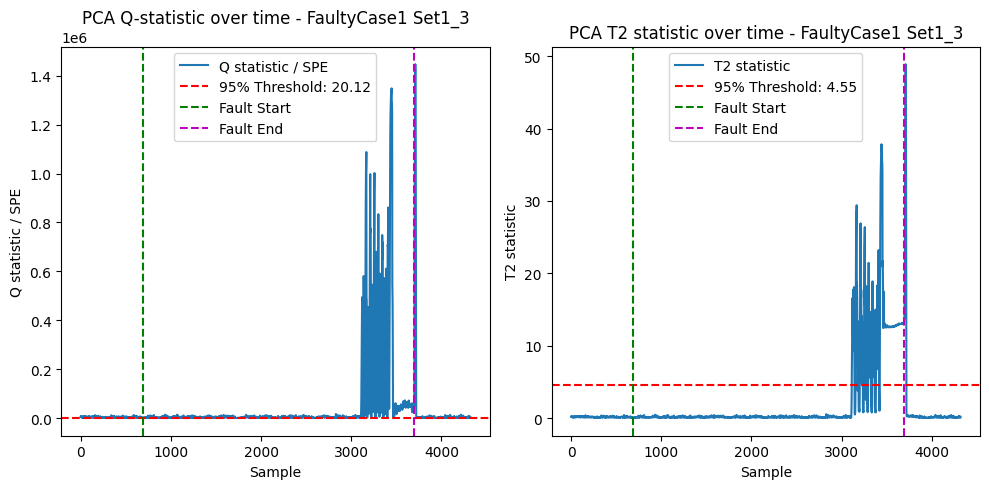

PCA on FaultyCase2 Set2_1: Number of Q-statistic anomalies: 9192 of 9192 samples
PCA on FaultyCase2 Set2_1: Number of T2 statistic anomalies: 13 of 9192 samples


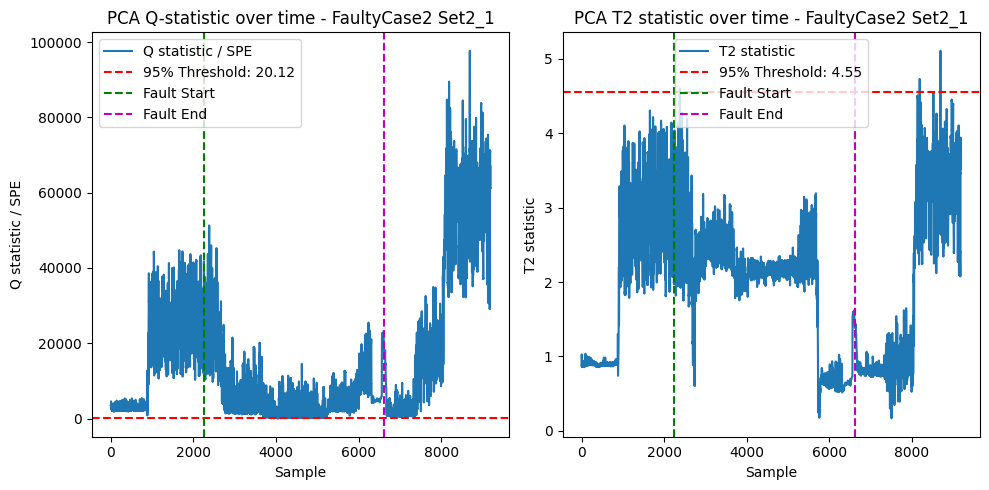

PCA on FaultyCase2 Set2_2: Number of Q-statistic anomalies: 3282 of 3496 samples
PCA on FaultyCase2 Set2_2: Number of T2 statistic anomalies: 352 of 3496 samples


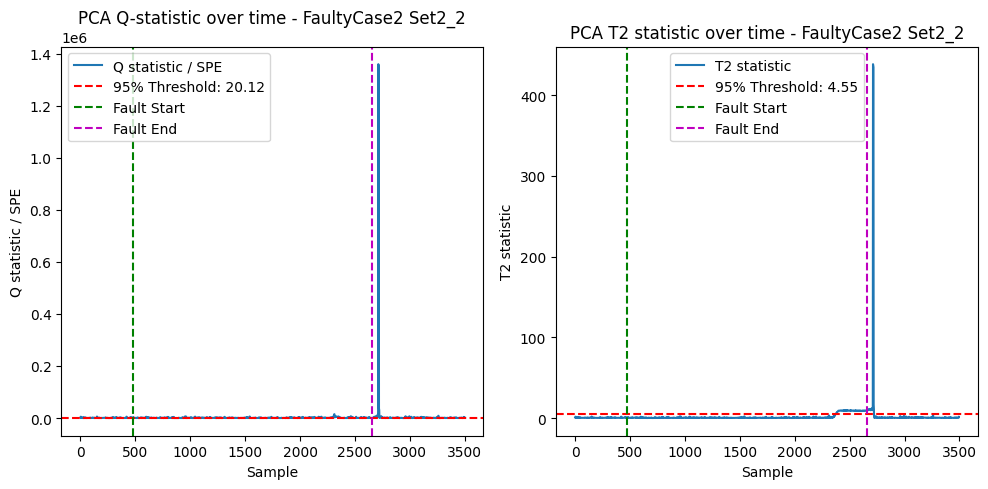

PCA on FaultyCase2 Set2_3: Number of Q-statistic anomalies: 3387 of 3421 samples
PCA on FaultyCase2 Set2_3: Number of T2 statistic anomalies: 356 of 3421 samples


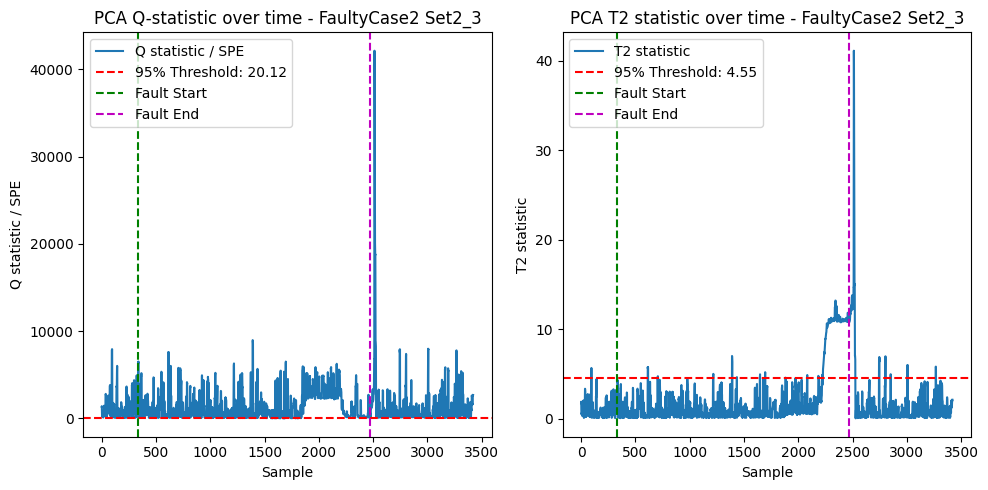

PCA on FaultyCase3 Set3_1: Number of Q-statistic anomalies: 9090 of 9090 samples
PCA on FaultyCase3 Set3_1: Number of T2 statistic anomalies: 984 of 9090 samples


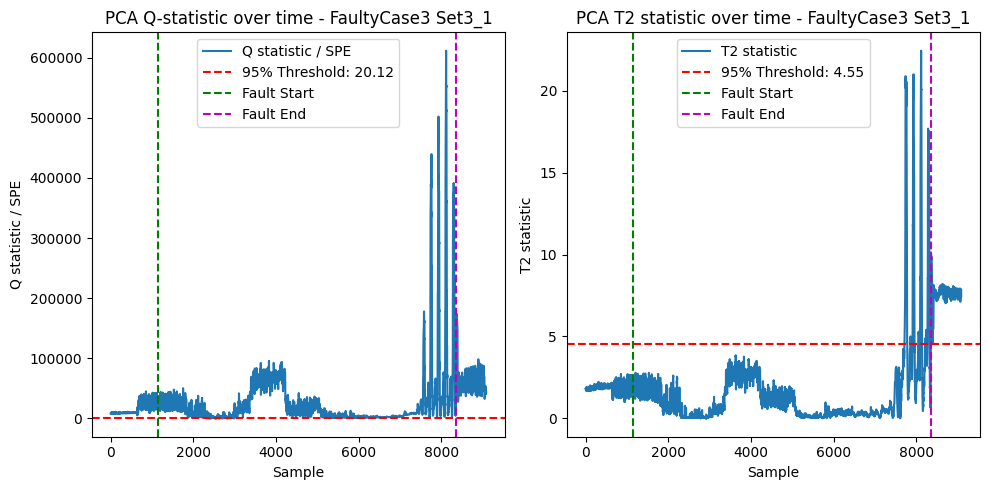

PCA on FaultyCase3 Set3_2: Number of Q-statistic anomalies: 6264 of 6272 samples
PCA on FaultyCase3 Set3_2: Number of T2 statistic anomalies: 297 of 6272 samples


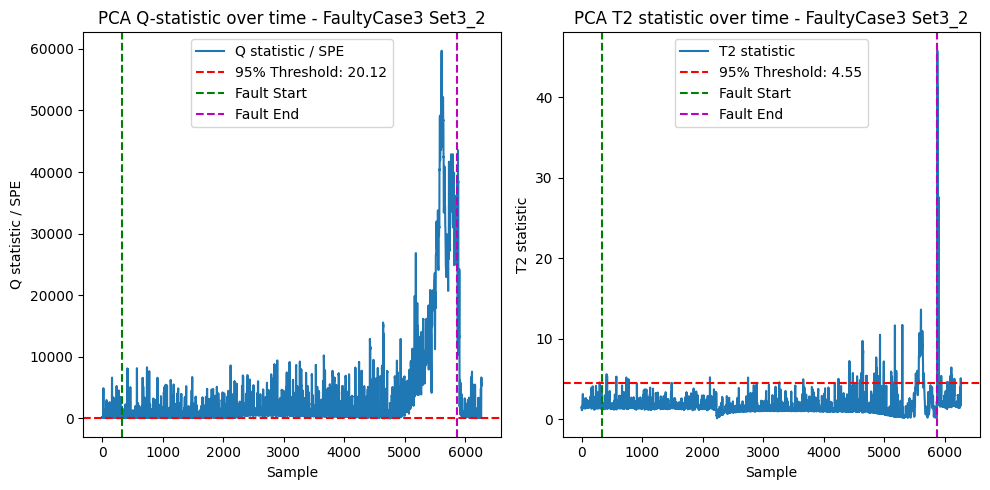

PCA on FaultyCase3 Set3_3: Number of Q-statistic anomalies: 10764 of 10764 samples
PCA on FaultyCase3 Set3_3: Number of T2 statistic anomalies: 593 of 10764 samples


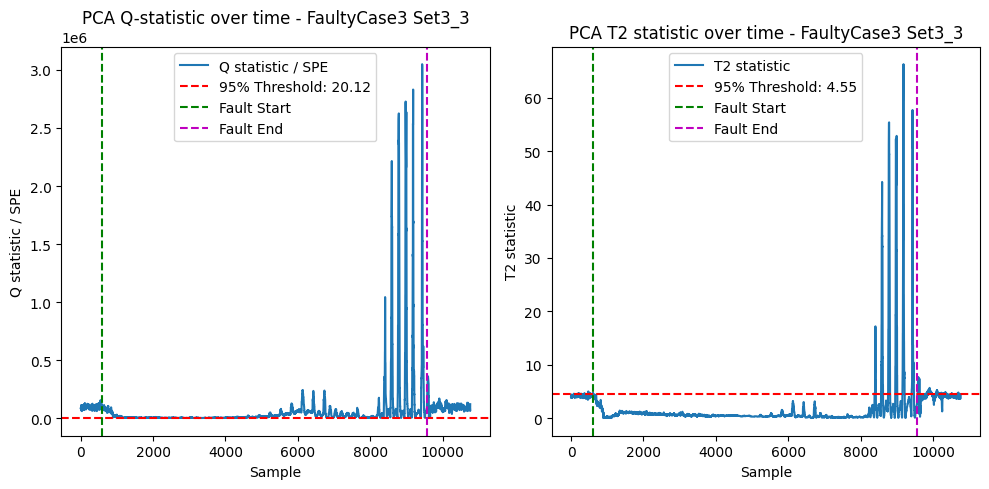

PCA on FaultyCase4 Set4_1: Number of Q-statistic anomalies: 7208 of 7208 samples
PCA on FaultyCase4 Set4_1: Number of T2 statistic anomalies: 1553 of 7208 samples


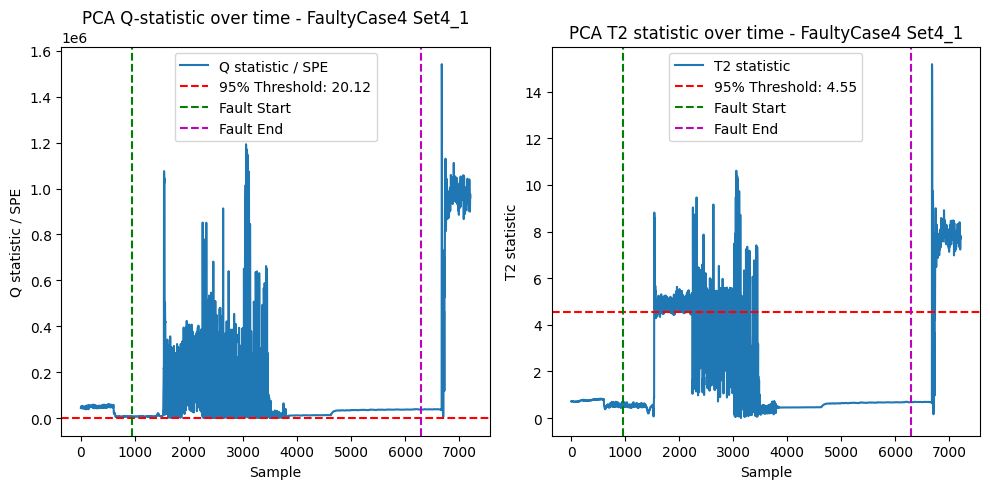

PCA on FaultyCase4 Set4_2: Number of Q-statistic anomalies: 4450 of 4451 samples
PCA on FaultyCase4 Set4_2: Number of T2 statistic anomalies: 205 of 4451 samples


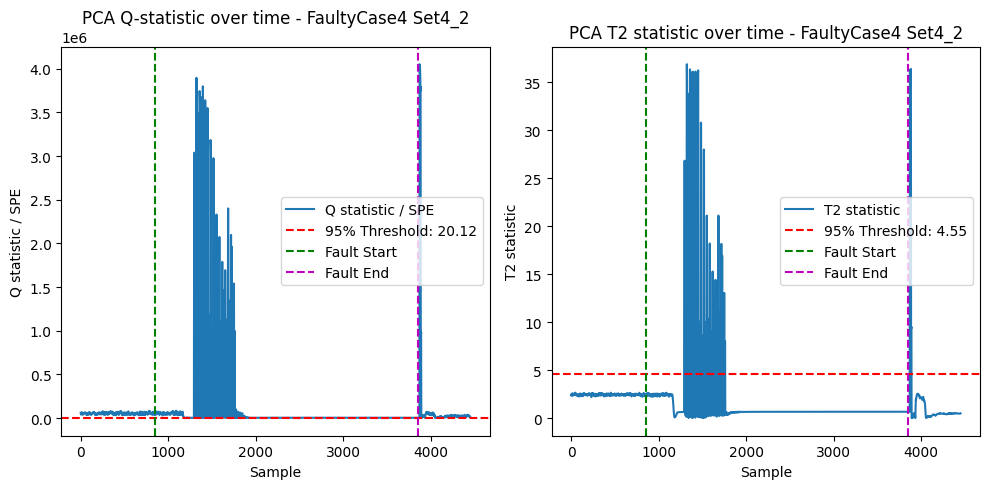

PCA on FaultyCase4 Set4_3: Number of Q-statistic anomalies: 3660 of 3661 samples
PCA on FaultyCase4 Set4_3: Number of T2 statistic anomalies: 300 of 3661 samples


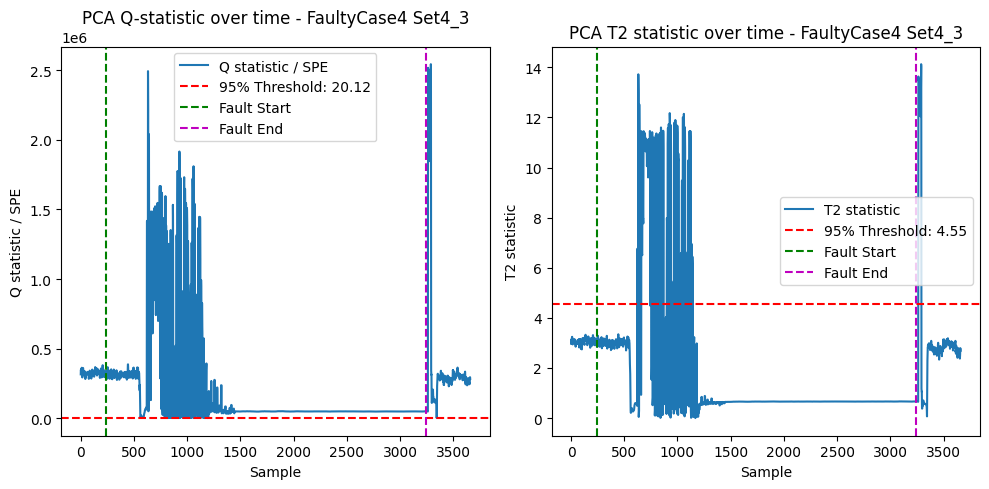

PCA on FaultyCase5 Set5_1: Number of Q-statistic anomalies: 2541 of 2541 samples
PCA on FaultyCase5 Set5_1: Number of T2 statistic anomalies: 385 of 2541 samples


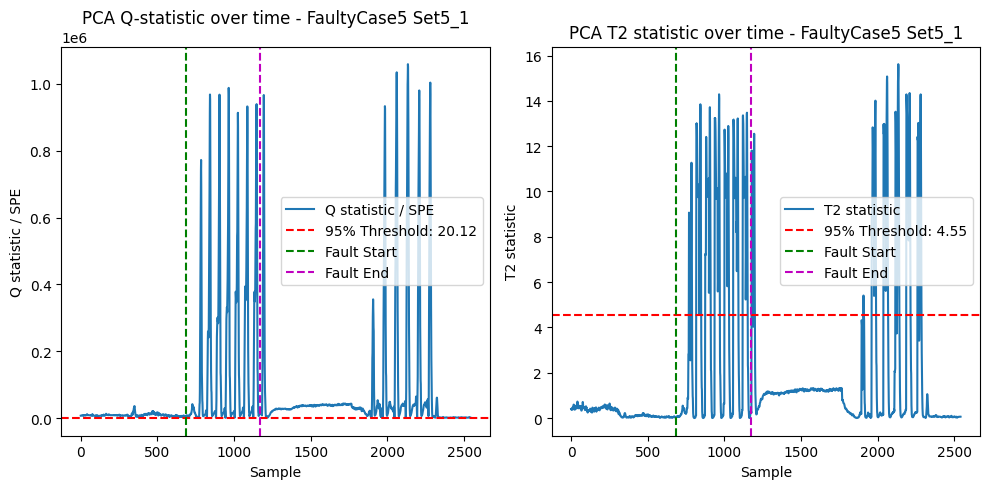

PCA on FaultyCase5 Set5_2: Number of Q-statistic anomalies: 10608 of 10608 samples
PCA on FaultyCase5 Set5_2: Number of T2 statistic anomalies: 2031 of 10608 samples


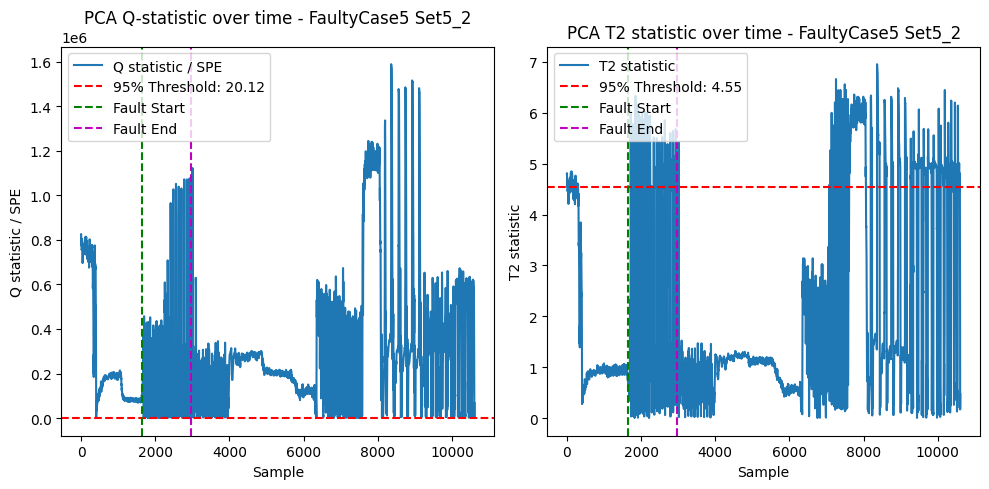

PCA on FaultyCase6 Set6_1: Number of Q-statistic anomalies: 2782 of 2800 samples
PCA on FaultyCase6 Set6_1: Number of T2 statistic anomalies: 206 of 2800 samples


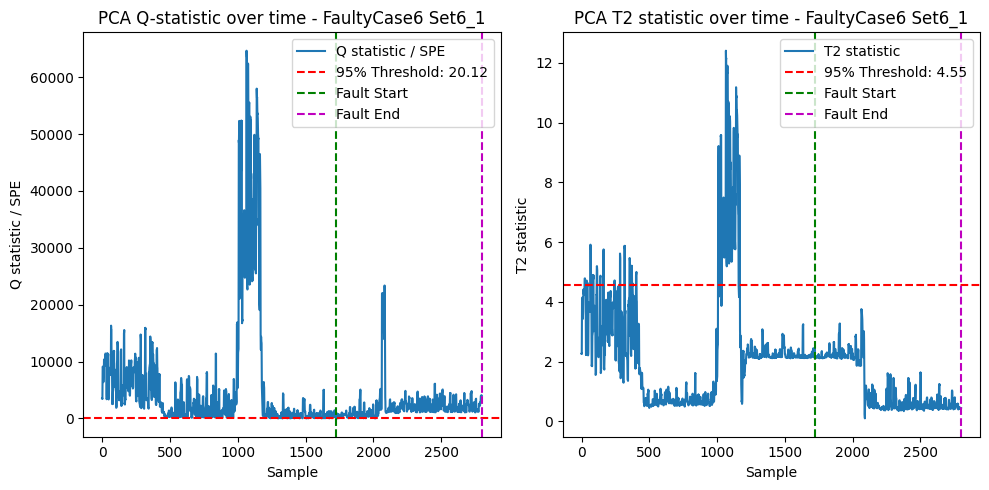

PCA on FaultyCase6 Set6_2: Number of Q-statistic anomalies: 4830 of 4830 samples
PCA on FaultyCase6 Set6_2: Number of T2 statistic anomalies: 314 of 4830 samples


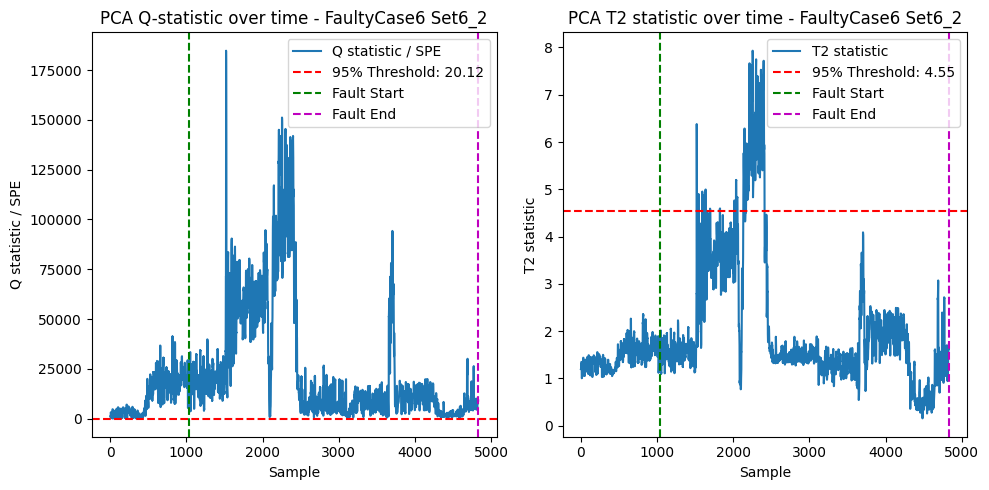

In [11]:
for case_name, case_sets in zip(se_windows.keys(), fc_sets):
    for set_name, fault_window in zip(case_sets.keys(), se_windows[case_name]):
        X_fault = case_sets[set_name].sensors
        Z_fault = pca_transform(X_fault, pca_model)
        q_fault = q_statistic(X_fault, Z_fault)
        t2_fault = t2_statistic(Z_fault)

        n_q_anomalies = np.sum(q_fault > threshold_q_pca)
        n_t2_anomalies = np.sum(t2_fault > threshold_t2_pca)

        print(f"PCA on {case_name} {set_name}: Number of Q-statistic anomalies: {n_q_anomalies} of {len(q_fault)} samples")
        print(f"PCA on {case_name} {set_name}: Number of T2 statistic anomalies: {n_t2_anomalies} of {len(t2_fault)} samples")

        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.plot(q_fault, label='Q statistic / SPE')
        plt.axhline(y=threshold_q_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_q_pca:.2f}')
        plt.axvline(x=fault_window[0], color='g', linestyle='--', label='Fault Start')
        plt.axvline(x=fault_window[1], color='m', linestyle='--', label='Fault End')
        plt.xlabel("Sample")
        plt.ylabel("Q statistic / SPE")
        plt.title(f"PCA Q-statistic over time - {case_name} {set_name}")
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.plot(t2_fault, label='T2 statistic')
        plt.axhline(y=threshold_t2_pca, color='r', linestyle='--', label=f'95% Threshold: {threshold_t2_pca:.2f}')
        plt.axvline(x=fault_window[0], color='g', linestyle='--', label='Fault Start')
        plt.axvline(x=fault_window[1], color='m', linestyle='--', label='Fault End')
        plt.xlabel("Sample")
        plt.ylabel("T2 statistic")
        plt.title(f"PCA T2 statistic over time - {case_name} {set_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()